# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Loading Dataset

In [2]:
df = pd.read_csv('Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA and Data Cleaning

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

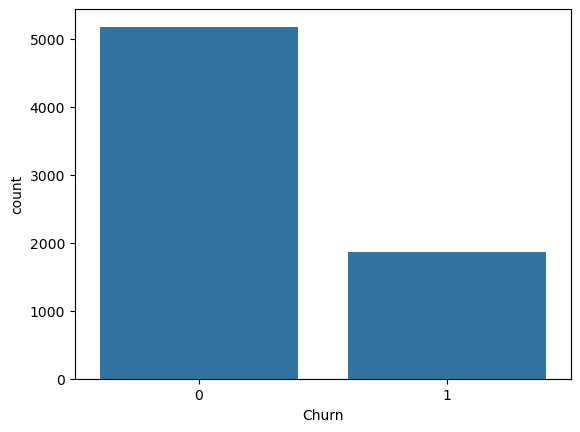

In [8]:
sns.countplot(x = 'Churn', data = df)
plt.show()

In [5]:
df.drop('customerID', axis = 1, inplace = True)

In [6]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


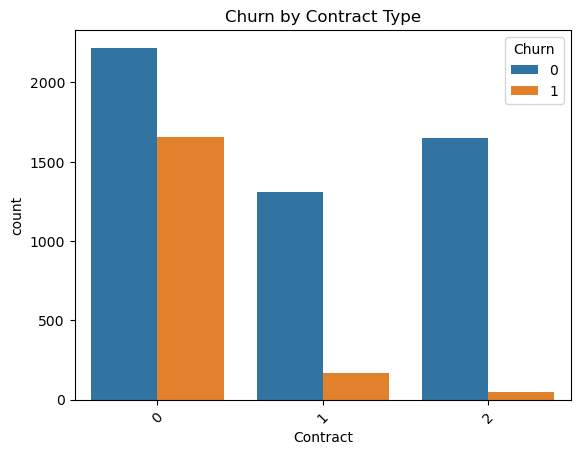

In [28]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=45)
plt.show()

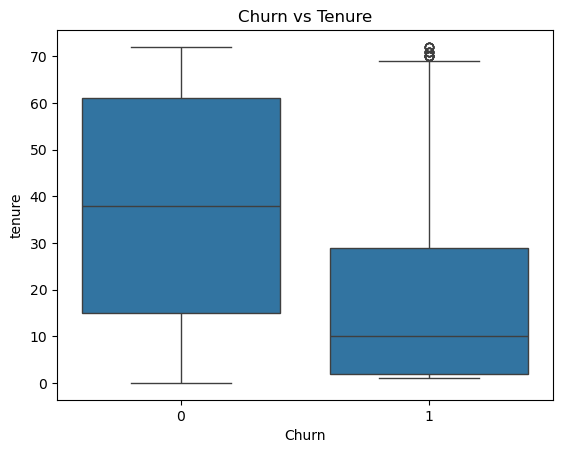

In [29]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Churn vs Tenure")
plt.show()

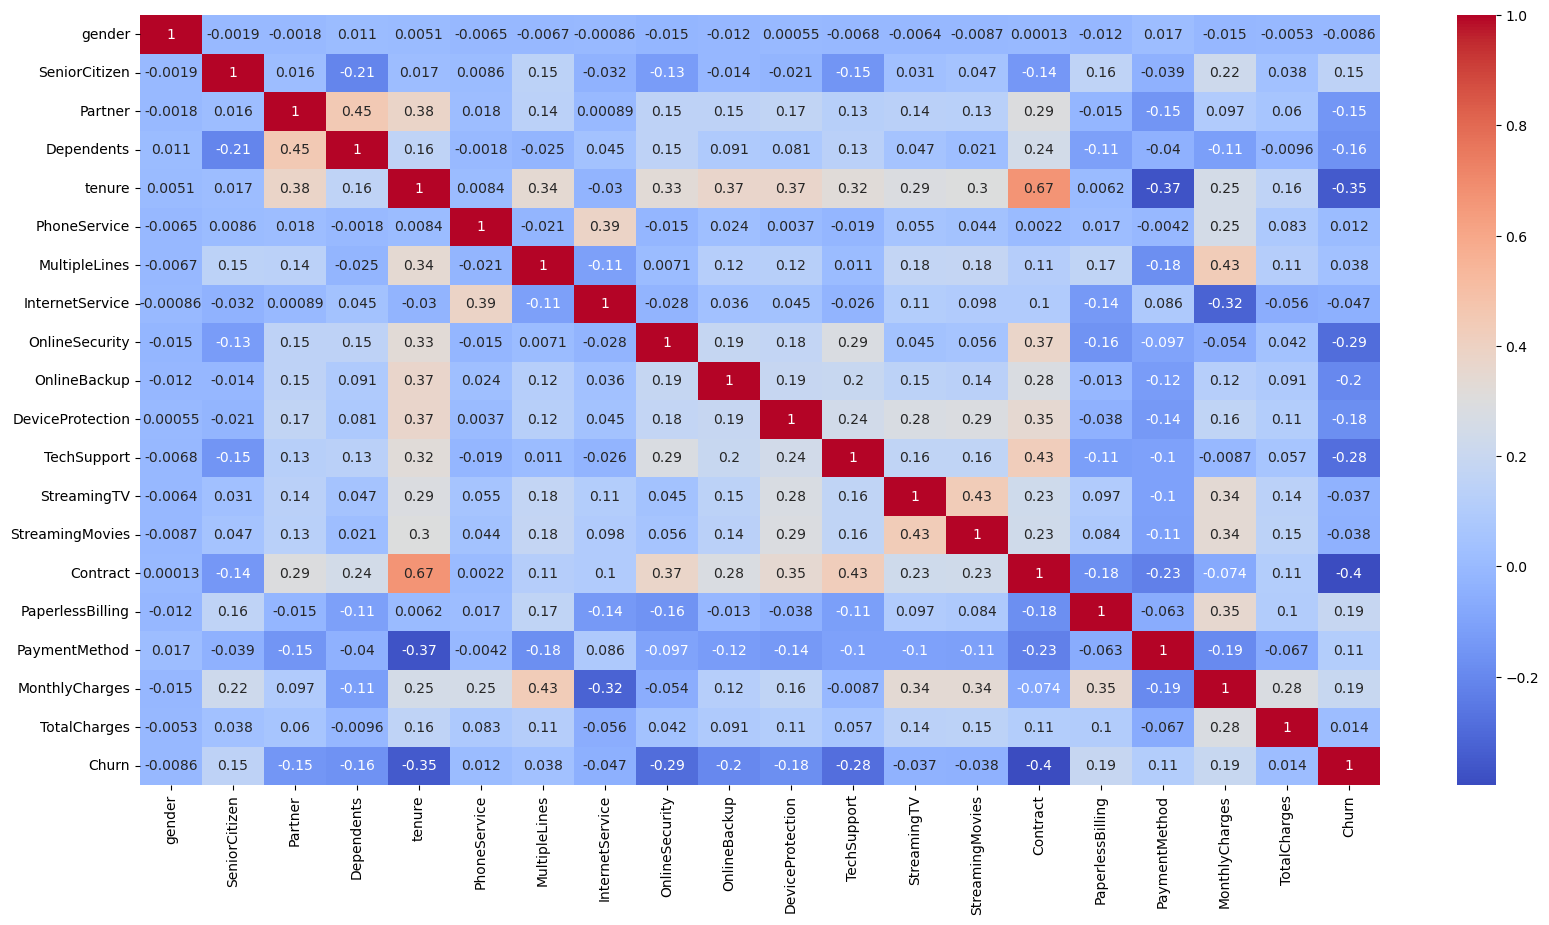

In [9]:
plt.figure(figsize = (20,10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.show()

In [7]:
le = LabelEncoder()

for col in df.select_dtypes(include = 'object').columns:
    df[col] = le.fit_transform(df[col])

# Handling Imbalanced Data

In [31]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_train, y_train = sm.fit_resample(X_train, y_train)

# Split Data

In [32]:
X = df.drop('Churn', axis = 1)
y = df['Churn']

X_train, X_test, y_train,y_test = train_test_split(
    X,y, test_size = 0.2, random_state = 42
)

# Feature Scaling

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Models

In [33]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [34]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [35]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

# Predictions

In [36]:
y_pred = rf.predict(X_test)

# Evaluate Model

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.78708303761533
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.53       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.77      1409



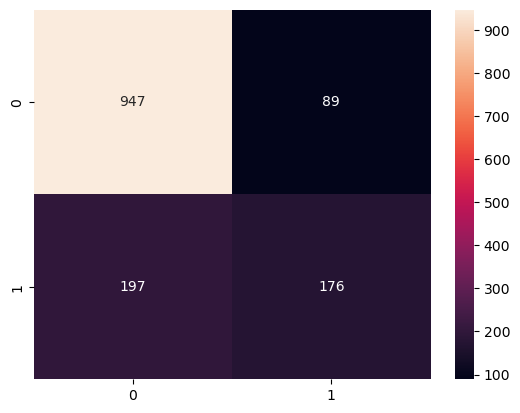

In [37]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

# Feature Importance

In [38]:
importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

             Feature  Importance
17    MonthlyCharges    0.177708
4             tenure    0.177186
18      TotalCharges    0.169894
14          Contract    0.077365
16     PaymentMethod    0.051158
8     OnlineSecurity    0.049190
11       TechSupport    0.041227
0             gender    0.027624
15  PaperlessBilling    0.026779
9       OnlineBackup    0.026609
2            Partner    0.024120
7    InternetService    0.023769
10  DeviceProtection    0.023155
6      MultipleLines    0.022970
1      SeniorCitizen    0.021064
3         Dependents    0.019782
13   StreamingMovies    0.018185
12       StreamingTV    0.017048
5       PhoneService    0.005166


In [39]:
import joblib

joblib.dump(rf, 'churn_model.pk1')

['churn_model.pk1']

In [40]:
!pip install --upgrade threadpoolctl

# Hyperparameter Tuning

In [41]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10], 'n_estimators': [100, 200]})

In [42]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


In [43]:
from sklearn.metrics import accuracy_score

train_pred = rf.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9985800496982605


In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8112136266855926
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [51]:
print("************************************")
print("Customer Churn Prediction Model")
print("************************************")



print("""

• Developed a machine learning classification model to predict customer churn.
• Performed data cleaning and preprocessing on the Telco Customer Churn dataset.
• Conducted EDA to identify key factors influencing customer churn.
• Applied Label Encoding and SMOTE to prepare the data for machine learning.
• Trained and compared Logistic Regression, Decision Tree, and Random Forest models.
• Evaluated models using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
• Performed overfitting analysis and Hyperparameter Tuning using GridSearchCV.
""")

print("************************************")
print("End Of The Project")
print("************************************")

************************************
Customer Churn Prediction Model
************************************


• Developed a machine learning classification model to predict customer churn.
• Performed data cleaning and preprocessing on the Telco Customer Churn dataset.
• Conducted EDA to identify key factors influencing customer churn.
• Applied Label Encoding and SMOTE to prepare the data for machine learning.
• Trained and compared Logistic Regression, Decision Tree, and Random Forest models.
• Evaluated models using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
• Performed overfitting analysis and Hyperparameter Tuning using GridSearchCV.

************************************
End Of The Project
************************************
